In [1]:
# # Branch Fusion — three-branch analysis and OpenAI reports
#
# Run these cells in order in Google Colab. This notebook reads the JSON and
# image outputs already saved by Branches 1, 2, and 3. It does not rerun their
# models.
#
# The numeric fusion is calculated locally and deterministically. OpenAI is then
# required to turn the locked evidence into two audience-specific reports.

# %% [markdown]
# ## Cell 1 — Mount Drive, install the OpenAI SDK, and locate the project
#
# The API key is not entered here and is never written to Drive.

# %%
from google.colab import drive
drive.mount("/content/drive")

!pip -q install "openai>=1.50,<3"

from pathlib import Path

PROJECT_DIRECTORY = Path(
    "/content/drive/MyDrive/Signature-Forensic-Prototype"
)
CONFIG_PATH = PROJECT_DIRECTORY / "config.yaml"

if not PROJECT_DIRECTORY.is_dir():
    raise FileNotFoundError(
        f"Project folder not found: {PROJECT_DIRECTORY}"
    )

print("Project directory:", PROJECT_DIRECTORY)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/Signature-Forensic-Prototype


In [2]:
# ## Cell 2 — Select the completed run
#
# If `RUN_DIRECTORY` still exists from Branch 1, it is reused. Otherwise this
# cell finds the newest run containing all three required JSON results.

# %%
required_relative_files = [
    Path("risk_fusion_result.json"),
    Path("branch2_geometry/branch2_geometry_result.json"),
    Path(
        "branch3_document_forensics/"
        "branch3_document_forensics.json"
    ),
]

existing_run = globals().get("RUN_DIRECTORY")
if existing_run is not None:
    candidate = Path(existing_run)
    if not all(
        (candidate / relative_path).is_file()
        for relative_path in required_relative_files
    ):
        existing_run = None

if existing_run is None:
    output_root = PROJECT_DIRECTORY / "outputs"
    compatible_runs = [
        path
        for path in output_root.iterdir()
        if path.is_dir()
        and all(
            (path / relative_path).is_file()
            for relative_path in required_relative_files
        )
    ]
    if not compatible_runs:
        raise FileNotFoundError(
            "No output run contains completed results from all three "
            "branches."
        )
    RUN_DIRECTORY = max(
        compatible_runs,
        key=lambda path: path.stat().st_mtime,
    )
else:
    RUN_DIRECTORY = Path(existing_run)

print("Selected run:", RUN_DIRECTORY)
for relative_path in required_relative_files:
    print("Found:", relative_path)

Selected run: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z
Found: risk_fusion_result.json
Found: branch2_geometry/branch2_geometry_result.json
Found: branch3_document_forensics/branch3_document_forensics.json


In [3]:
# ## Cell 3 — Add the transparent fusion settings to config.yaml
#
# These are starting research settings, not clinically or legally validated
# thresholds. Reliability modifies each configured branch weight before the
# three risks are combined.

# %%
import yaml

current_config = yaml.safe_load(
    CONFIG_PATH.read_text(encoding="utf-8")
) or {}

current_config.setdefault(
    "branch_fusion",
    {
        "openai_model": "gpt-5.6-terra",
        "api_key_environment_variable": "OPENAI_API_KEY",
        "branch_weights": {
            "branch1": 0.45,
            "branch2": 0.35,
            "branch3": 0.20,
        },
        "branch2_maximum_reliability": 0.50,
        "branch2_pairs_for_full_reliability": 20,
        "branch3_limited_feature_factor": 0.75,
        "minimum_reliability_for_lower_priority": 0.60,
        "lower_review_boundary": 0.30,
        "elevated_review_boundary": 0.65,
    },
)

CONFIG_PATH.write_text(
    yaml.safe_dump(current_config, sort_keys=False),
    encoding="utf-8",
)
print("Branch-fusion configuration is available.")

Branch-fusion configuration is available.


In [4]:
# ## Cell 4 — Verify and import the Branch Fusion source files
#
# Copy the `src/branch_fusion` folder supplied with this stage into the Drive
# project before running this cell.

# %%
import importlib
import sys

BRANCH_FUSION_DIRECTORY = (
    PROJECT_DIRECTORY / "src/branch_fusion"
)
required_module_files = [
    "__init__.py",
    "evidence.py",
    "fusion.py",
    "visualization.py",
    "reports.py",
    "pipeline.py",
]
missing_modules = [
    name
    for name in required_module_files
    if not (BRANCH_FUSION_DIRECTORY / name).is_file()
]
if missing_modules:
    raise FileNotFoundError(
        "Copy these files into src/branch_fusion: "
        + str(missing_modules)
    )

if str(PROJECT_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIRECTORY))

for module_name in list(sys.modules):
    if (
        module_name == "src.branch_fusion"
        or module_name.startswith("src.branch_fusion.")
    ):
        del sys.modules[module_name]

importlib.invalidate_caches()
from src.branch_fusion import (
    generate_required_reports,
    prepare_branch_fusion,
    save_branch_fusion_outputs,
)

print("Branch Fusion modules imported.")

Branch Fusion modules imported.


In [5]:
# ## Cell 5 — Load the three saved branches and calculate fusion
#
# This is the reproducible numeric step. The LLM is not used to calculate or
# change the branch risks, weights, reliability, or final conclusion.

# %%
import json

fusion_bundle = prepare_branch_fusion(
    RUN_DIRECTORY,
    CONFIG_PATH,
)
fusion_result = fusion_bundle["fusion"]

print("DETERMINISTIC BRANCH FUSION")
print("===========================")
print(json.dumps(fusion_result, indent=2))


DETERMINISTIC BRANCH FUSION
{
  "case_id": "20260727T153721_774776Z",
  "fusion_type": "deterministic_three_branch_review_fusion",
  "branch_risks": {
    "branch1": 0.363993,
    "branch2": 0.564432,
    "branch3": 0.220142
  },
  "configured_weights": {
    "branch1": 0.45,
    "branch2": 0.35,
    "branch3": 0.2
  },
  "branch_reliabilities": {
    "branch1": 0.725068,
    "branch2": 0.5,
    "branch3": 0.75
  },
  "effective_weights": {
    "branch1": 0.500983,
    "branch2": 0.268701,
    "branch3": 0.230315
  },
  "fused_review_risk": 0.38472,
  "conclusion": "manual_review",
  "quality_limited": true,
  "cross_branch_agreement": {
    "branch1_review_indicator": true,
    "branch2_review_indicator": true,
    "branch3_review_indicator": false,
    "review_indicator_count": 2,
    "summary": "Branches 1 and 2 both indicate comparative inconsistency while Branch 3 did not trigger a digital-reuse warning."
  },
  "reasons": [
    "Branch 1 decision: manual_review",
    "Branch 2 re

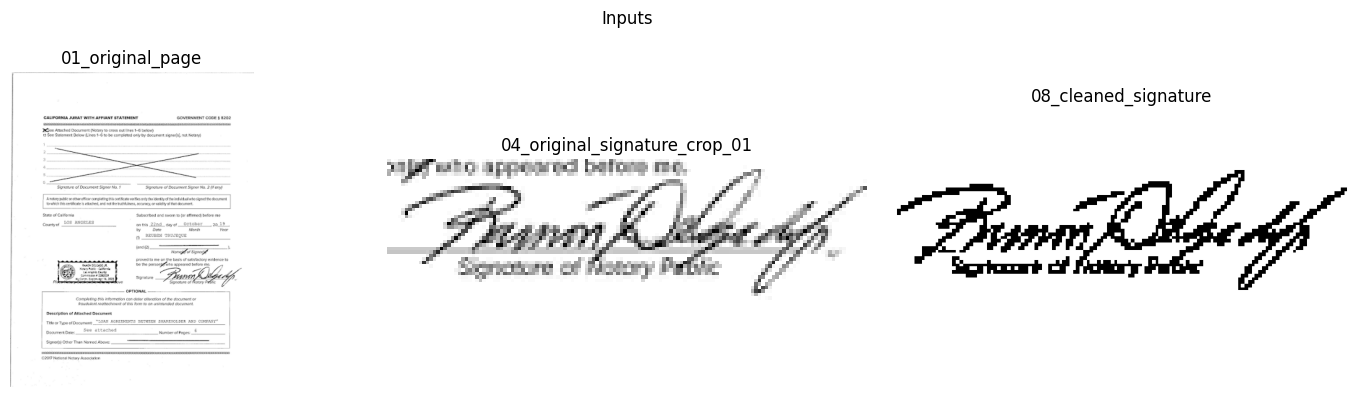

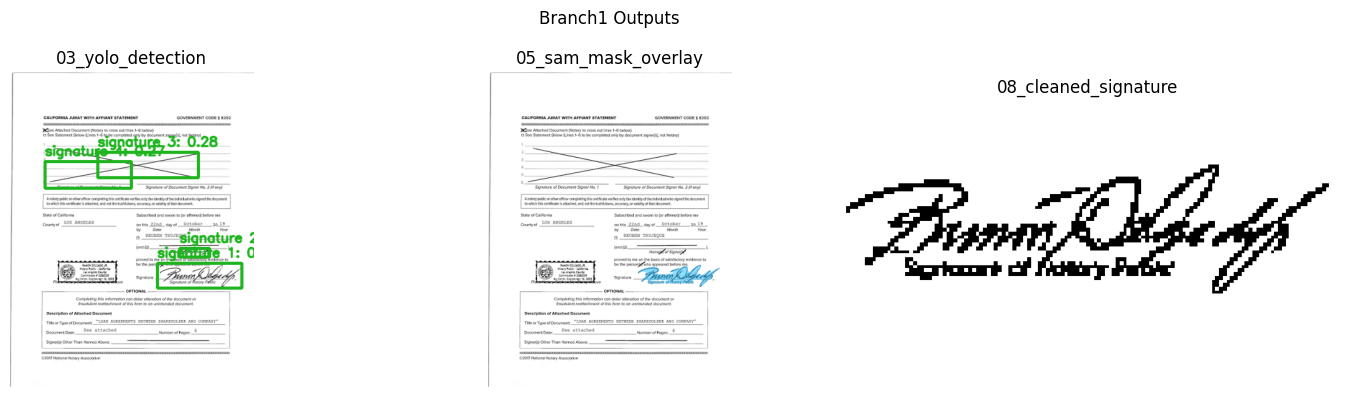

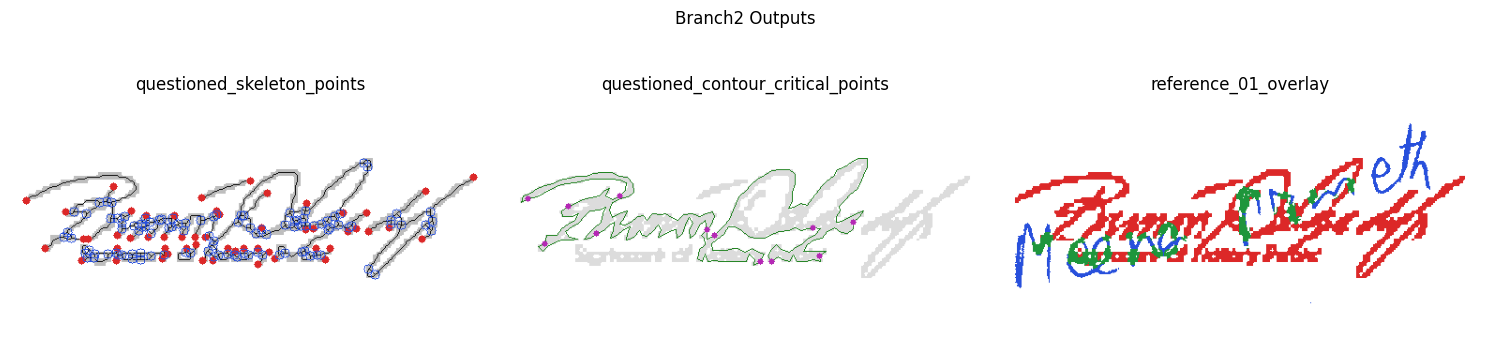

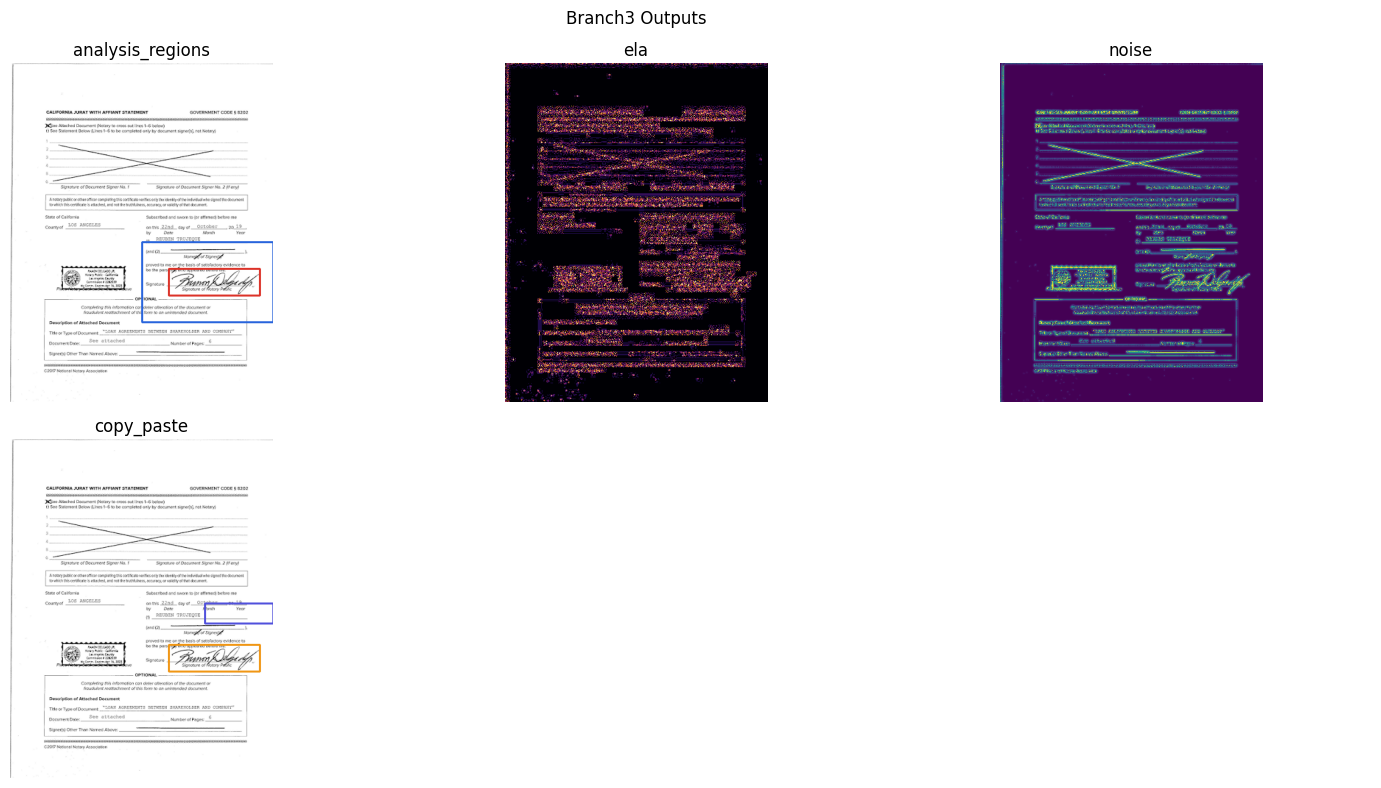

In [6]:
# ## Cell 6 — Show the input and branch-output evidence images
#
# Images are read from the same run. Missing optional visual files are skipped
# without affecting the JSON fusion.

# %%
import math
import matplotlib.pyplot as plt
from PIL import Image

for group_name, image_paths in fusion_bundle["images"].items():
    if not image_paths:
        print(group_name, ": no saved images found")
        continue

    columns = min(3, len(image_paths))
    rows = math.ceil(len(image_paths) / columns)
    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(5 * columns, 4 * rows),
    )
    axes = [axes] if len(image_paths) == 1 else axes.ravel()

    for axis, image_path in zip(axes, image_paths):
        axis.imshow(Image.open(image_path))
        axis.set_title(Path(image_path).stem)
        axis.axis("off")
    for axis in axes[len(image_paths):]:
        axis.axis("off")

    figure.suptitle(group_name.replace("_", " ").title())
    plt.tight_layout()
    plt.show()

In [7]:
# ## Cell 7 — Enter the OpenAI API key securely
#
# An OpenAI API call is required for both reports. `getpass` hides the key while
# you type, and the key remains only in this Colab runtime.

# %%
import getpass
import os

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass(
        "Enter your OpenAI API key: "
    ).strip()

if not os.environ["OPENAI_API_KEY"]:
    raise ValueError("An OpenAI API key is required.")

print("OpenAI API key is available in runtime memory.")

Enter your OpenAI API key: ··········
OpenAI API key is available in runtime memory.


In [8]:
# ## Cell 8 — Generate the senior and technical reports with OpenAI
#
# Two separate prompts are used because the audiences need different depth.
# Only compact structured evidence is sent; saved evidence images are not sent.
# The returned reports are checked for required sections and unsupported claims.

# %%
openai_reports = generate_required_reports(
    fusion_bundle
)

print("OpenAI reports generated with:")
print(json.dumps(openai_reports["metadata"], indent=2))

OpenAI reports generated with:
{
  "provider": "OpenAI",
  "model": "gpt-5.6-terra",
  "reports_generated": 2,
  "images_sent_to_model": false
}


In [10]:
# ## Cell 9 — Display both reports

# %%
from IPython.display import Markdown, display

display(Markdown(openai_reports["senior_report"]))
display(Markdown(openai_reports["technical_report"]))

# Senior Stakeholder Report

## Executive conclusion

**Case:** 20260727T153721_774776Z  
The authoritative deterministic fusion conclusion is **manual_review**, with a fused review risk of **0.38472**. This result is quality-limited.

Two of three branches indicated comparative inconsistency; the document-forensics branch did not trigger a digital-reuse warning, but its feature evidence was limited. Lower-priority output was blocked by evidence-quality or validation limitations. The appropriate next step is qualified human examination.

## Three-branch summary

- **Branch 1 — Learned verification:** **manual_review**; overall risk **0.363993**.  
  Available indicators require human comparison. The Siamese status was **elevated_inconsistency**, but its verification contribution was down-weighted because external generalization is weak. Quality warnings included conservative cleaning fallback and **0 of 5 references aligned**.

- **Branch 2 — Structural AI:** branch risk **0.564432**; relative status **below_observed_reference_variation**.  
  The questioned mean combined shape similarity was **0.5102996**, compared with a reference similarity median of **0.64222878** and 10th percentile of **0.57061727**, across **10** reference pairs. Questioned combined shape similarities ranged from **0.48837599** to **0.56177333**.

- **Branch 3 — Document forensics:** **no_elevated_indicators_limited_feature_evidence**; overall screening risk **0.220142**.  
  No configured screening threshold was exceeded. However, ORB crop-to-page analysis was inconclusive because the signature crop had **0** keypoints, while the page had **1855**. No possible second location was reported. Compression and noise outputs remain screening indicators with stated limitations.

The fusion applied effective weights of **0.500983** for Branch 1, **0.268701** for Branch 2, and **0.230315** for Branch 3. Branches 1 and 2 both indicated comparative inconsistency; Branch 3 did not trigger a digital-reuse warning.

## Business implications

- Do not treat the current result as suitable for automatic clearance or disposition.
- Preserve the source document, signature crop, and all five references for review.
- Prioritize a qualified examiner’s comparison because the result is quality-limited and two branches require review.
- The absence of an elevated document-forensics indicator does not establish that editing did not occur.

## Recommended actions

1. Route the case for qualified human examination of the questioned signature and available references.
2. Obtain higher-quality source material or originals, if available, to address the alignment and feature-evidence limitations.
3. Review the reference set, including the fact that **0 of 5 references aligned** in Branch 1 and that Branch 3 had **0** reference ORB features available.
4. Retain the case record and underlying files so that any subsequent examination can assess image quality, capture conditions, and reference comparability.
5. Avoid automated closure based on Branch 3’s lack of elevated indicators, given its inconclusive keypoint evidence.

## Limitations and disclaimer

This fused result is a review-priority synthesis, not a probability or finding of authenticity, forgery, editing, intent, or legal validity.

Branch 1 was limited by document-quality warnings, conservative cleaning fallback, failed reference alignment, and weak untouched CEDAR generalization. Branch 3’s ORB crop-to-page evidence was inconclusive because of insufficient stable crop keypoints. ELA may be affected by PDF rendering, scanning, image resizing, and repeated compression. Noise inconsistency is not specific to editing and may vary with ink density, paper texture, shadows, scanning, and compression.

Model outputs are screening evidence, not legal or forensic conclusions. This is not an authenticity, forgery, intent, or legal-validity determination. Any consequential use requires qualified human examination.

# Technical Fusion Report

## Scope and evidence

Case `20260727T153721_774776Z` was assessed through a deterministic three-branch review fusion:

1. Learned verification and quality assessment
2. Structural AI comparison against available references
3. Document-forensics screening

The authoritative fusion type is `deterministic_three_branch_review_fusion`. The fused result is `manual_review`, with `fused_review_risk` of `0.38472`. The fusion is marked `quality_limited: true`.

The available evidence includes five reference comparisons in the structural branch, document-level compression and noise screening, multiscale template matching, and limited crop-to-page feature analysis. The evidence does not establish an authenticity, forgery, intent, editing, or legal-validity conclusion.

## Branch 1 — Learned verification and quality

Branch 1 returned `manual_review` with `overall_risk` of `0.363993`. Its component risks were:

| Component | Risk |
|---|---:|
| Verification | `0.703663` |
| Quality | `0.274932` |
| Forensic | `0.40128` |
| Duplicate | `0.21225` |

The branch reports that available indicators require human comparison. Its Siamese status was `elevated_inconsistency`; however, the branch also states that the Siamese score cannot support a provisional-consistency outcome because untouched CEDAR generalization was weak. This limitation reduces the reliability of an automated interpretation of the verification signal.

Quality and processing limitations further constrain this branch:

- The document had one or more quality warnings.
- A conservative cleaning fallback preserved the original ink.
- `0 of 5 references aligned`.
- The verification contribution was down-weighted because external generalization is weak.

Although Branch 1’s own reported `reliability` field is `null`, the deterministic fusion assigned Branch 1 a reliability of `0.725068`. This assigned fusion reliability should be understood as part of the configured fusion process, not as a separately reported validation result for the branch output.

## Branch 2 — Structural AI

Branch 2 reported the relative status `below_observed_reference_variation`. The questioned comparison statistics were:

| Statistic | Value |
|---|---:|
| Questioned mean | `0.5102996` |
| Questioned median | `0.49708535` |
| Questioned minimum | `0.48837599` |
| Questioned maximum | `0.56177333` |
| Reference pair count | `10` |
| Reference similarity median | `0.64222878` |
| Reference similarity 10th percentile | `0.57061727` |

The five combined shape similarities against the available references were `0.49155256`, `0.49708535`, `0.51271077`, `0.48837599`, and `0.56177333`.

Each comparison used the same normalized metric weights:

| Metric | Normalized weight |
|---|---:|
| Hu | `0.15` |
| Fourier | `0.2` |
| Shape context | `0.25` |
| Contour | `0.15` |
| Graph | `0.15` |
| Critical points | `0.1` |

The reported metric-level results show differing behavior across structural descriptors. Fourier similarities were comparatively high across the reported comparisons, ranging from `0.86638921` to `0.91909248`. Shape-context similarities ranged from `0.655175` to `0.77469169`, while Hu similarities ranged from `0.03763616` to `0.07164031`. Contour similarities were very low, including `0.0` for reference 4 and values from `4.22e-06` to `0.00089085` for the remaining references. Graph and critical-points similarities also varied across references.

The deterministic fusion assigns Branch 2 a branch risk of `0.564432` and a reliability of `0.5`. Its lower reliability, relative to Branches 1 and 3, limits its influence despite its higher branch risk. No Branch 2 warnings were reported.

## Branch 3 — Document forensics

Branch 3 returned `no_elevated_indicators_limited_feature_evidence` with `overall_screening_risk` of `0.220142`. Its component risks were:

| Component | Risk |
|---|---:|
| Copy/paste | `0.067806` |
| Compression | `0.262652` |
| Noise | `0.719396` |
| Duplicate | `0.0` |

The branch reported that no configured screening threshold was exceeded, while also identifying limited feature evidence. In particular, ORB crop-to-page analysis was inconclusive because the signature crop had insufficient stable keypoints:

- Crop keypoint count: `0`
- Page keypoint count: `1855`
- Feature-method status: `inconclusive_insufficient_keypoints`
- Outside-source good matches: `0`
- RANSAC inliers: `0`
- RANSAC inlier ratio: `0.0`

A multiscale template fallback was available and reported separately:

- Template match score: `0.195281`
- Template scale: `0.75`
- Template phase response: `0.193147`
- Template candidate bounding box: `[291, 246, 393, 276]`
- Source bounding box: `[237, 308, 373, 348]`
- Possible second location: `false`

Compression-screening measurements were:

| Measure | Value |
|---|---:|
| Inside-signature ELA mean | `1.901103` |
| Outside-signature ELA mean | `0.792538` |
| Outside-signature ELA standard deviation | `1.688264` |
| Local ELA z-score | `0.65663` |
| Block-boundary difference | `8.830195` |
| Nonboundary difference | `8.674966` |
| Blockiness ratio | `1.017894` |
| JPEG quality | `90` |

Noise-analysis measurements were:

| Measure | Value |
|---|---:|
| Inside residual standard deviation | `3.749564` |
| Surrounding residual standard deviation | `5.372739` |
| Residual standard deviation ratio | `0.697887` |
| Absolute residual mean difference | `0.725229` |
| Inside flat-pixel count | `2174` |
| Surrounding flat-pixel count | `12102` |
| Flat-gradient threshold | `12.0` |

Branch 3 reports complete evidence coverage of `1.0`, but this coverage includes methods with limited or inconclusive feature evidence. Availability was reported as follows: crop-to-page ORB `false`, multiscale template `true`, compression `true`, noise `true`, reference hashing `true`, reference ORB available count `0`, and reference comparison count `5`.

The absence of an elevated Branch 3 indicator does not establish that no document-level alteration or other process occurred. Its own warnings state that ELA can be affected by PDF rendering, scanning, image resizing, and repeated compression; likewise, noise inconsistency is not specific to any one process and can vary with ink density, paper texture, shadows, scanning, and compression.

## Fusion method and result

The deterministic fusion used the following configured weights:

| Branch | Configured weight | Reliability | Effective weight | Branch risk |
|---|---:|---:|---:|---:|
| Branch 1 | `0.45` | `0.725068` | `0.500983` | `0.363993` |
| Branch 2 | `0.35` | `0.5` | `0.268701` | `0.564432` |
| Branch 3 | `0.2` | `0.75` | `0.230315` | `0.220142` |

The authoritative fused review risk is `0.38472`, and the authoritative conclusion is `manual_review`.

This result follows the configured deterministic fusion rather than a recalculation or statistical interpretation. Branches 1 and 2 both supplied review indicators: Branch 1 returned `manual_review`, and Branch 2 reported `below_observed_reference_variation`. Branch 3 did not trigger a digital-reuse warning and returned `no_elevated_indicators_limited_feature_evidence`.

The cross-branch summary states: “Branches 1 and 2 both indicate comparative inconsistency while Branch 3 did not trigger a digital-reuse warning.” Accordingly, the fusion records `review_indicator_count` of `2`.

Branch 1 had the largest effective weight, `0.500983`, reflecting its configured weight and assigned reliability. Branch 2 had the highest branch risk, `0.564432`, but a lower effective weight of `0.268701` because its assigned reliability was `0.5`. Branch 3 had the lowest branch risk, `0.220142`, and an effective weight of `0.230315`; however, its feature-based copy/paste analysis was inconclusive due to zero crop keypoints. The quality-limited status and the reported weak external generalization prevented a lower-priority output from being accepted. The fusion reasons expressly state that a lower-priority output was blocked by evidence-quality or validation limitations.

## Evidence gaps

- Branch 1 reported `0 of 5 references aligned`, limiting direct aligned-reference comparison.
- The Branch 1 Siamese verification output was down-weighted because untouched CEDAR generalization was weak.
- Branch 1 reported document quality warnings and use of a conservative cleaning fallback.
- Branch 2 provided structural comparison results but no warnings or separate reliability validation evidence beyond the fusion-assigned reliability of `0.5`.
- Branch 3 crop-to-page ORB analysis was inconclusive: the crop had `0` keypoints despite `1855` page keypoints.
- Branch 3 had `0` reference ORB features available.
- Template matching was available, but it is reported as a fallback separate from the inconclusive ORB analysis.
- Compression and noise findings are screening evidence with stated non-specific limitations.
- No statistical calibration is supplied for branch risks, fused review risk, similarity values, or reliability values.

## Validation recommendations

- Conduct qualified human examination of the questioned material and the available references, with attention to the comparative inconsistencies identified by Branches 1 and 2.
- Review the source-document acquisition and rendering history where available, because the Branch 3 limitations identify scanning, PDF rendering, resizing, and repeated compression as factors that can affect screening indicators.
- Obtain or preserve higher-quality source material and additional suitable reference material where available, particularly because `0 of 5 references aligned` and crop-to-page ORB analysis had insufficient stable keypoints.
- Evaluate the Branch 1 learned-verification output in light of its stated weak untouched CEDAR generalization and down-weighting.
- Treat the Branch 3 result as limited screening evidence rather than an exclusionary result, given the inconclusive ORB crop-to-page evidence and the stated limitations of ELA and noise analysis.
- Retain the reported branch-level outputs, fusion weights, effective weights, and quality limitations for reproducibility of the deterministic review-priority result.

## Technical disclaimer

The fused result is a review-priority synthesis, not a probability or finding of authenticity, forgery, editing, intent, or legal validity. Model outputs and document-forensics indicators are screening evidence, not legal or forensic conclusions. A lack of an elevated indicator in any branch does not prove that a particular process did not occur. Any consequential use requires qualified human examination.

BRANCH FUSION COMPLETED
Conclusion: manual_review
Fused review risk: 0.38472

Saved outputs:
- fusion_result: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/branch_fusion/branch_fusion_result.json
- report_evidence: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/branch_fusion/report_evidence.json
- senior_report: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/branch_fusion/senior_stakeholder_report.md
- technical_report: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/branch_fusion/technical_fusion_report.md
- report_metadata: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/branch_fusion/report_metadata.json
- dashboard: /content/drive/MyDrive/Signature-Forensic-Prototype/outputs/20260727T153721_774776Z/branch_fusion/branch_fusion_dashboard.png


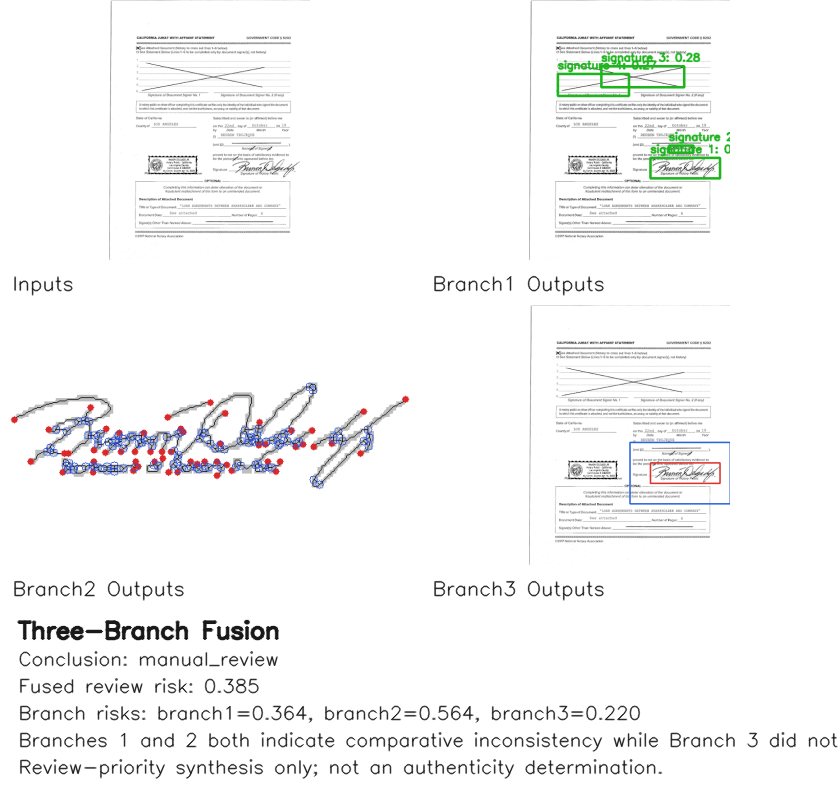


This is a prototype review-priority synthesis, not an authenticity, forgery, editing, intent, or legal-validity determination.


In [12]:
# ## Cell 10 — Save reports, fusion JSON, evidence JSON, and dashboard
#
# Everything is written into a new `branch_fusion` subfolder inside the selected
# run. The dashboard includes representative input and output images.

# %%
saved_fusion_paths = save_branch_fusion_outputs(
    fusion_bundle,
    openai_reports,
)

print("BRANCH FUSION COMPLETED")
print("=======================")
print("Conclusion:", fusion_result["conclusion"])
print(
    "Fused review risk:",
    fusion_result["fused_review_risk"],
)
print("\nSaved outputs:")
for artifact_name, artifact_path in saved_fusion_paths.items():
    print(f"- {artifact_name}: {artifact_path}")

# Display the saved dashboard as the final visual summary.
display(
    Image.open(saved_fusion_paths["dashboard"])
)

print(
    "\nThis is a prototype review-priority synthesis, "
    "not an authenticity, forgery, editing, intent, or "
    "legal-validity determination."
)